In [2]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

Text(0, 0.5, 'U')

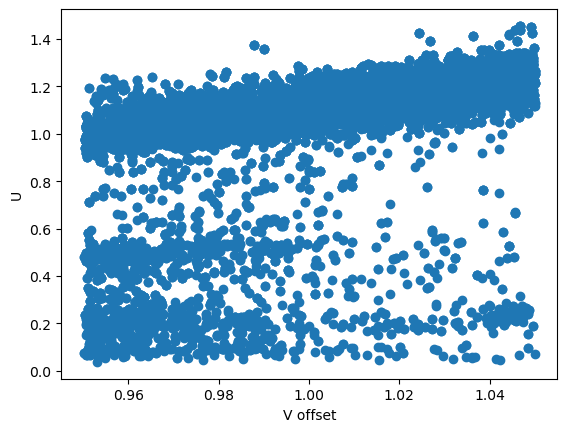

In [3]:
plt.scatter(dat["V_offset"].flatten(), dat["U_i"].flatten())
plt.xlabel("V offset")
plt.ylabel("U")

Text(0, 0.5, 'U')

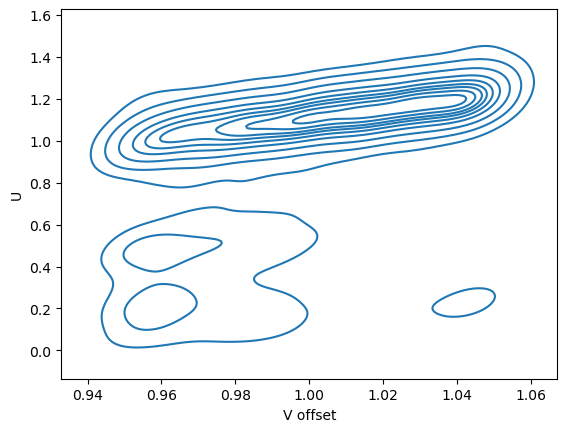

In [4]:
sns.kdeplot(x=dat["V_offset"].flatten(), y=dat["U_i"].flatten())
plt.xlabel("V offset")
plt.ylabel("U")

In [7]:
import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
dat["rij"] = np.zeros(
    (
        dat["trap_centers"].shape[0],
        dat["trap_centers"].shape[1],
        dat["trap_centers"].shape[1],
    )
)
dat["rx_ij"] = np.zeros(
    (
        dat["trap_centers"].shape[0],
        dat["trap_centers"].shape[1],
        dat["trap_centers"].shape[1],
    )
)
dat["ry_ij"] = np.zeros(
    (
        dat["trap_centers"].shape[0],
        dat["trap_centers"].shape[1],
        dat["trap_centers"].shape[1],
    )
)

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)

Set rij as the distance between the ith and jth points in the dataset.

Text(0, 0.5, 'tij')

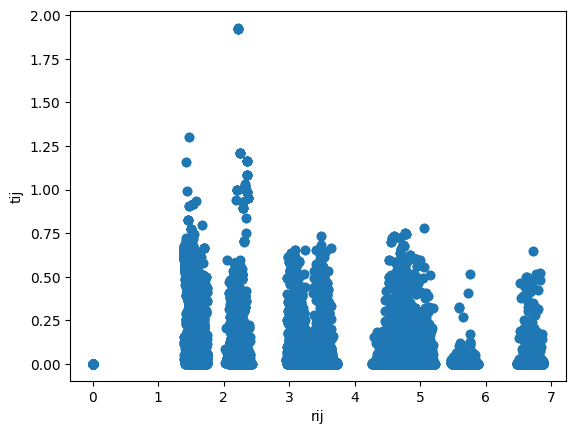

In [19]:
plt.scatter(dat["rij"].flatten(), dat["t_ij"].flatten())
plt.xlabel("rij")
plt.ylabel("tij")

(-0.05, 0.5)

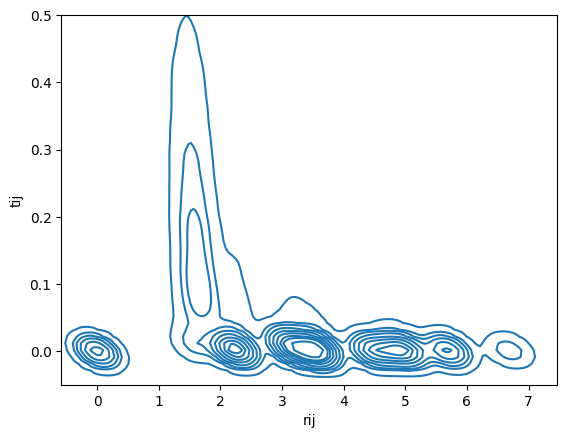

In [24]:
sns.kdeplot(x=dat["rij"].flatten(), y=dat["t_ij"].flatten())
plt.xlabel("rij")
plt.ylabel("tij")
plt.ylim(0.05, 0.50)

t_ii = 0 is enforeced:

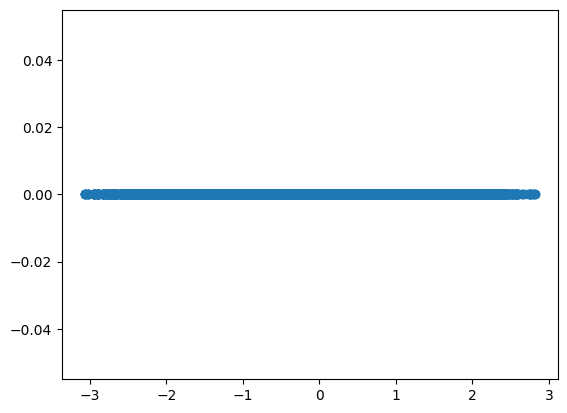

In [13]:
plt.scatter(dat["V_i"].flatten(), dat["t_ij"].diagonal(axis1=1, axis2=2).flatten())

In [26]:
np.sum(dat["t_ij"] < 0)

0

(1.25, 1.9)

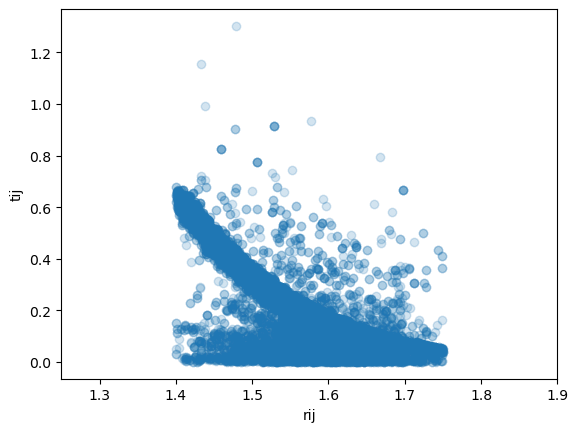

In [9]:
mask = dat["rij"].flatten() < 1.9

plt.scatter(x=dat["rij"].flatten()[mask], y=dat["t_ij"].flatten()[mask], alpha=0.1)
plt.xlabel("rij")
plt.ylabel("tij")
plt.xlim(1.25, 1.9)

(1.25, 1.9)

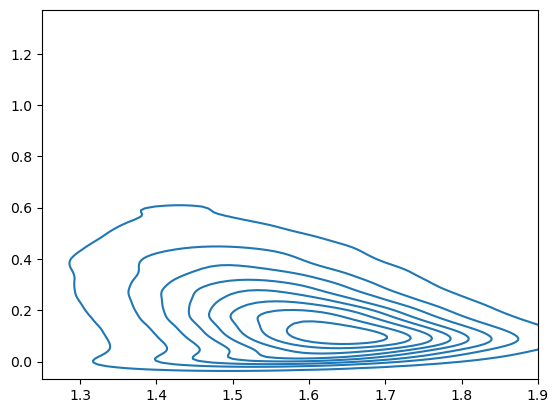

In [10]:
sns.kdeplot(x=dat["rij"].flatten()[mask], y=dat["t_ij"].flatten()[mask])
plt.xlim(1.25, 1.9)